# Importación de los datos
Importación del dataset y lectura de sus características

In [71]:
import pandas as pd

DATOS = pd.read_csv("housing.csv")

In [72]:
DATOS.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [73]:
DATOS.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [74]:
DATOS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [75]:
DATOS.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
# 2 opciones: Eliminar los valores nulos o replazarlos con la media
data_non_null = DATOS.dropna()
data_non_null.info()

data_clean = DATOS.copy()
data_clean["total_bedrooms"] = data_clean["total_bedrooms"].fillna(value=data_clean["total_bedrooms"].mean())

#  Imprimimos para ver si la media cambia:
# Parece que 'total_bedrooms' no cambia (Si cambias los datos nulos por la media no alteras la media global)
# Pero otros valores si pueden cambiar (Si eliminas datos con 'total_bedrooms' nulos, realmente estás borrando
# esa fila de datos entera, por lo que eliminas ese valor del conteo de la media)
print("\ntotal_bedrooms:")
print(f"Media sin valores nulos:  {data_non_null["total_bedrooms"].mean()}")
print(f"Media imputando la media: {data_clean["total_bedrooms"].mean()}")

print("\nhousing_median_age:")
print(f"Media sin valores nulos:  {data_non_null["housing_median_age"].mean()}")
print(f"Media imputando la media: {data_clean["housing_median_age"].mean()}")

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB

total_bedrooms:
Media sin valores nulos:  537.8705525375618
Media imputando la media: 537.8705525375617

housing_median_age:
Media sin valores nulos:  28.633093525179856
Media imputando la media: 28.639486434108527


# Visualización de los datos
Mediante matplotlib y pandas

In [ ]:
# Elijo quedarme con el dataframe sin datos nulos (y sin imputación de datos)
data = data_non_null

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Historiograma ---
plt.style.use('_mpl-gallery')
# Creamos los ejes de la figura
fig, ax = plt.subplots(figsize=(8, 8))
"""
nrows, ncols: Número de subplots en cada línea/columna 
"""

# Elejimos que datos mostrar
x = np.array(DATOS["total_rooms"])

# Dibujamos el historiograma
ax.hist(x, linewidth=0.5, edgecolor="white", bins=100)
"""
bins: Número de barras
linewidth, edgecolor: Cambiar gráficos
range [tuple]: Indica el rango de los datos 
"""

plt.show()

In [ ]:
# --- Dibujamos varios gráficos ---

def plotGraphs(data):
    """
    Crea 4 gráficos para el conjunto de datos especificado. No muestra datos muy relevantes, simplemente prueba a mostrar datos en diferentes plots
    """
    
    plt.style.use('_mpl-gallery')
    # Creamos los ejes de la figura
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), layout="constrained")
    """
    nrows, ncols: Número de subplots en cada línea/columna 
    """

    # Elejimos que datos mostrar
    y = np.array(data["median_house_value"])
    x = np.linspace(0, len(y), len(y))

    # Dibujamos cada gráfico
    ax1.set_title("median_house_value")
    ax1.hist(y, bins=20, linewidth=0.5, edgecolor="white",color="green")

    ax2.set_title("latitude vs longitude")
    ax2.scatter(np.array(data["latitude"]), np.array(data["longitude"]), color="green")
    # ax2.scatter(
    #     np.array(data["median_house_value"]),
    #     np.array(data["total_rooms"]),
    #     color="green",
    # )

    ax3.set_title("median_house_value")
    population = data["population"]
    boxplot_data = [np.multiply(y, 0.01), population]
    labels = ["Median house value (x0.01)", "Population"]
    ax3.set_xticklabels(labels)
    ax3.boxplot(boxplot_data, showmeans=True, showfliers=True)

    ax4.set_title("ocean_proximity")
    x_categorica = data["ocean_proximity"].unique()
    y_categorica = np.array(data["ocean_proximity"].value_counts())
    ax4.bar(x_categorica, y_categorica, linewidth=0.5, color="blue")

    plt.show()
    print("Categóricas:\n", x_categorica, y_categorica)

    print("\nPopulation:")
    print(f"Mean: {population.mean()}, Median: {population.median()}, Min: {population.min()}, Max: {population.max()}")
    print(f"Std: {population.std()}, Var (std^2): {population.var()}")

In [ ]:
plotGraphs(data)

In [ ]:
def plotBoxplots(data, rows=2, cols=5):
    """
    Muestra un boxplot para cada valor numérico de 'data'
    """
    
    
    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")

    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 6), layout="constrained")
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.boxplot(data, showmeans=True, showfliers=True)
        
    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()

In [ ]:
plotBoxplots(data)

In [ ]:
# Algunos tests para ver que valores son atípicos y cuales no

habitaciones = data["total_rooms"] / data["households"]
print("mediana", habitaciones.mean())

Q1, Q3 = habitaciones.quantile([0.25, 0.75])
rango_intercuartil = Q3 - Q1
print(Q1, Q3, rango_intercuartil)
print("outliers", Q3 + rango_intercuartil * 1.5)

fig, ax = plt.subplots(figsize=(10, 3))
x = np.array(habitaciones)

# Dibujamos el historiograma
ax.hist(x, linewidth=0.5, edgecolor="white")
plt.show()
print(habitaciones.max())

También se pueden mostrar gráficos con pandas. Son métodos más sencillos, pero dan menos juego
Además, parece que solo se pueden mostrar de uno en uno (y no en forma de cuadrícula como matplotlib)

In [ ]:
# --- Gráficos con pandas ---
# Gráfico 1
data["median_house_value"].plot.hist()
plt.figure()

# Gráfico 2
data.plot.scatter(x="median_income", y="median_house_value")
plt.figure()

# Gráfico 3
data.boxplot(column="population", grid=True)
plt.figure()

# Gráfico 4
data["ocean_proximity"].value_counts().plot.bar()
plt.figure() # El último se puede omitir con pandas

### Eliminamos outliers de todas las variables
Para cada variable, miramos cada uno de sus valores y eliminamos los que estén por muy alejados de la media (1.5 * RangoIntercuartil)

ERROR: Hay valores que, aunque están alejados de la mediana, no deberían considerarse *outliers*
Quizá hay que preprocesar algunas columnas de datos antes de aplicar el "algoritmo" de eliminación de outliers

In [ ]:
# --- Eliminación de outliers ---

separacion_maxima = 1.5
data_sin_outliers = data.copy()

# Solo nos interesan las variables numéricas, no categóricas
variables_numericas = data_sin_outliers.select_dtypes(include="number")
print(list(variables_numericas.columns))

for col in variables_numericas.columns:
    columnName = variables_numericas[col]
    # print("\n", col, "\n", column)

    # IQR o RI: Rango intercuartil
    Q1, Q3 = variables_numericas[col].quantile([0.25, 0.75])
    rango_intercuartil = Q3 - Q1
    print(col, Q1, Q3, rango_intercuartil)

    # Eliminamos los outliers por encima del valor especificado
    """ data_limpio = data[(data["columna"] >= Q1 - 1.5 * IQR) & (data["columna"] <= Q3 + 1.5 * IQR)] """
    # Para cambiar todas a la vez: data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]
    data_sin_outliers = data_sin_outliers[
        (data_sin_outliers[col] >= Q1 - separacion_maxima * rango_intercuartil)
        & (data_sin_outliers[col] <= Q3 + separacion_maxima * rango_intercuartil)
    ]

In [77]:
# Comprobamos si se han eliminado outliers de 'population' y 'median_house_value'

def printInfo(df, columnName):
    variable = df[columnName]
    print(f"{columnName.upper()}:")
    print(
        f"Mean: {variable.mean()}, Median: {variable.median()}, Min: {variable.min()}, Max: {variable.max()}"
    )
    print(f"Std: {variable.std()}")

printInfo(data, "population")
printInfo(data_sin_outliers, "population")
print()
printInfo(data, "median_house_value")
printInfo(data_sin_outliers, "median_house_value")

POPULATION:
Mean: 1424.9469485635982, Median: 1166.0, Min: 3.0, Max: 35682.0
Std: 1133.2084897449556
POPULATION:
Mean: 1197.1082941378916, Median: 1111.0, Min: 3.0, Max: 3124.0
Std: 601.851012913499

MEDIAN_HOUSE_VALUE:
Mean: 206864.41315519012, Median: 179700.0, Min: 14999.0, Max: 500001.0
Std: 115435.6670985836
MEDIAN_HOUSE_VALUE:
Mean: 187056.1888264311, Median: 170100.0, Min: 14999.0, Max: 482200.0
Std: 93742.85915897976


In [ ]:
# También podemos visualizar los datos
# plotGraphs(data)
# plotGraphs(data_sin_outliers)

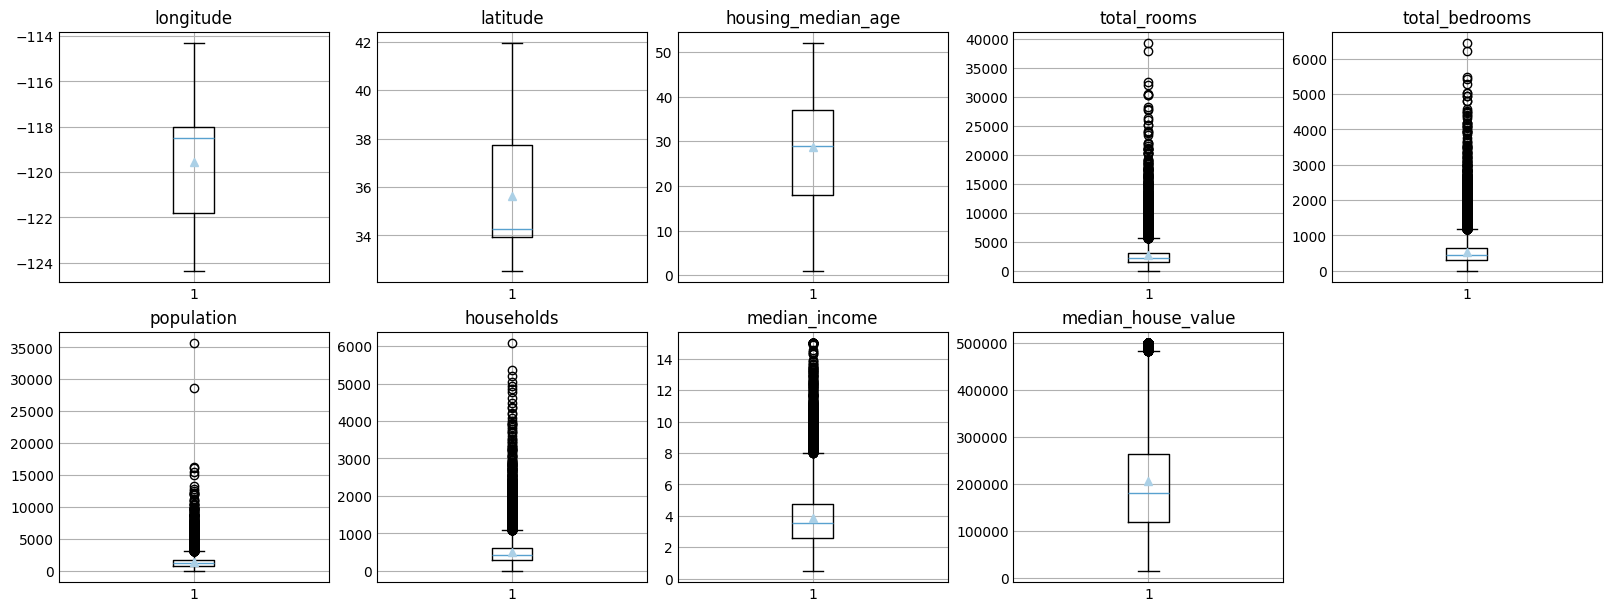

DATA SIN OUTLIERS


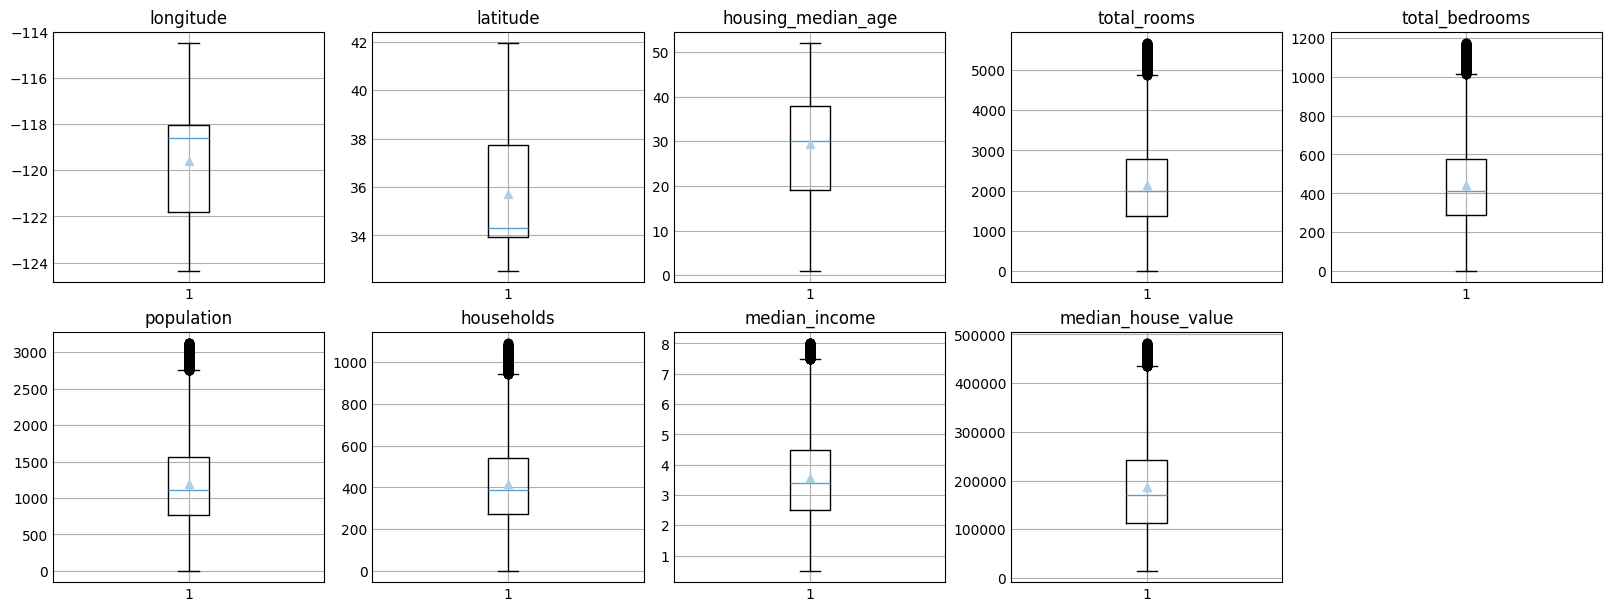

In [78]:
# Y como boxplots
plotBoxplots(data)
print("DATA SIN OUTLIERS")
plotBoxplots(data_sin_outliers)

In [79]:
data_sin_outliers.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000
mean,-119.605773,35.697862,29.489216,2144.865206,445.472697,1197.108294,416.806126,3.575593,187056.188826
std,2.004422,2.166633,12.214437,1088.703854,221.276085,601.851013,205.412687,1.443540,93742.859159
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.790000,33.940000,19.000000,1377.000000,287.000000,766.250000,271.000000,2.490150,112900.000000
50%,-118.610000,34.310000,30.000000,1979.000000,411.000000,1111.000000,387.000000,3.390600,170100.000000
75%,-118.030000,37.740000,38.000000,2782.000000,578.000000,1559.000000,540.000000,4.487950,241600.000000
max,-114.490000,41.950000,52.000000,5675.000000,1173.000000,3124.000000,1090.000000,8.011300,482200.000000


# Notas aparte

In [ ]:
# NOTAS APARTE
# house = data.iloc[i, :] # Para mirar casa por casa